In [10]:
import pandas as pd

file_path = "/content/flux_comparison_2.xlsx"

try:
    df = pd.read_excel(file_path, sheet_name="Nonzero_floating_point_correct")
    display(df.head(3))
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Please check the file path.")
except Exception as e:
    print(f"An error occurred: {e}")

n=len(df)
print(n)


,Reaction Number,Reaction ID,Reaction Label,Broad Label,color,BL order,Old Model Flux,New Model Flux,Flux Difference (New - Old),Absolute Flux Difference,Sign Changed,Old Flux correct,New Flux correct,Difference correct
0,238,EX_h_LPAREN_e_RPAREN_,Extracellular exchange,Transport,blue,1,0.039599,0.004374,-0.035225,0.035225,False,0.039599,0.004374,-0.035225
1,1869,GLNtN1,"Transport, Extracellular",Transport,blue,1,0.019888,0.002381,-0.017507,0.017507,False,0.019888,0.002381,-0.017507
2,339,EX_pyr_LPAREN_e_RPAREN_,Extracellular exchange,Transport,blue,1,-0.007551,-0.000567,0.006983,0.006983,False,-0.007551,-0.000567,-0.006983


222


In [7]:
colorDict = {'Transport': 'blue', 'Carbohydrates': 'orange', 'Lipids': 'green', 'Amino Acids': 'red',
             'Nucleic Acids': 'purple', 'Other': 'brown', 'Energy': 'magenta', 'Vitamins and cofactors': 'gray'}

In [8]:
handles = []
sns.set_palette("bright")
for c in colorDict:
    handles.append(mpatches.Patch(color= colorDict[c], label= c))

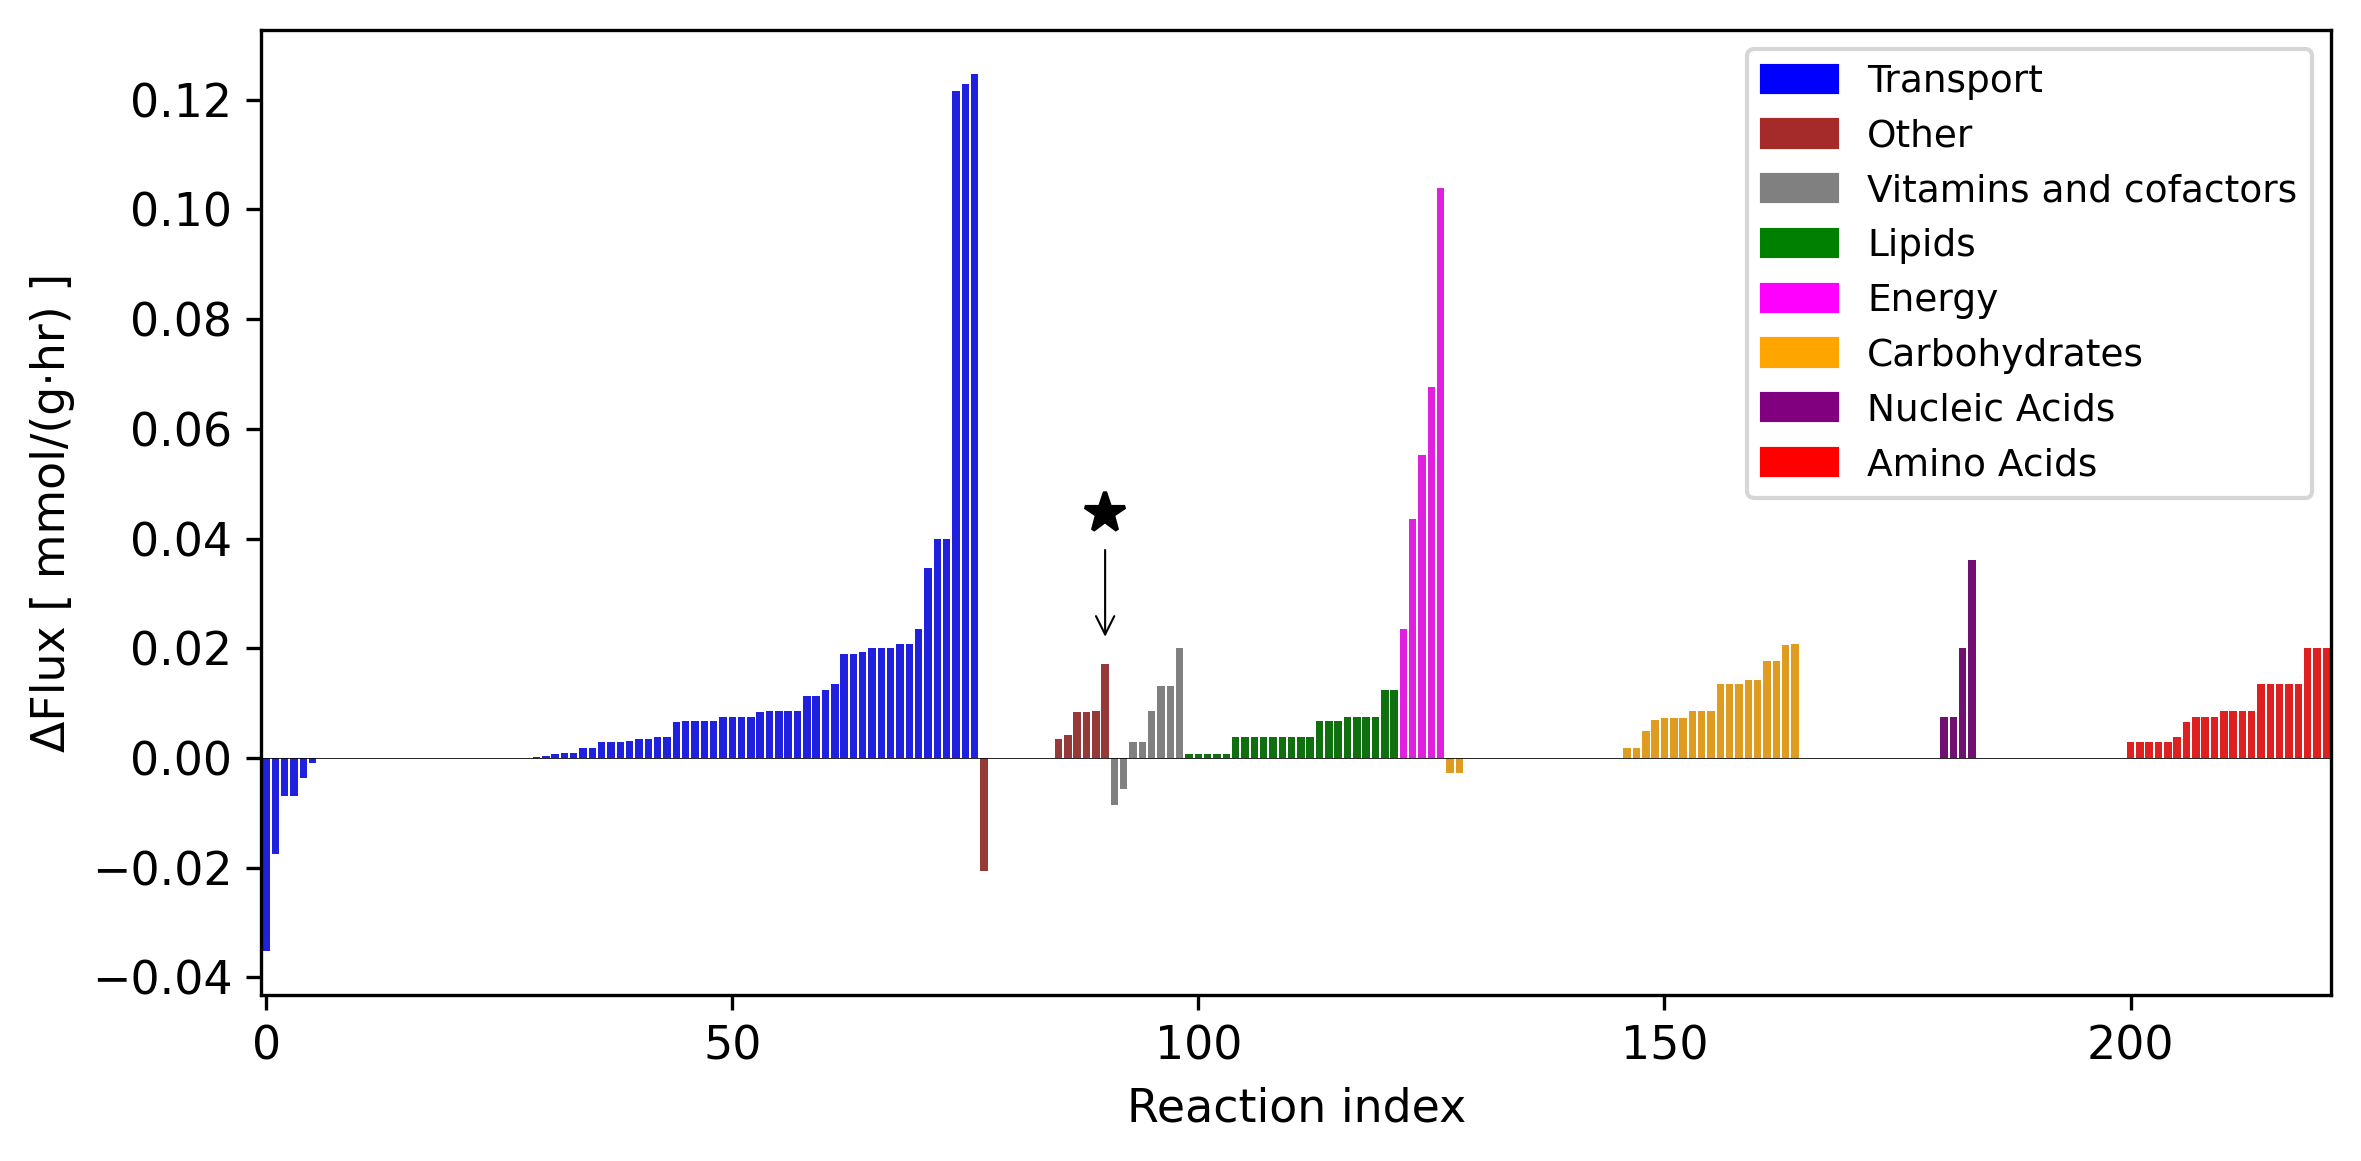

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import pandas as pd

# Define the desired order for broad labels
category_order = [
    'Transport',
    'Other',
    'Vitamins and cofactors',
    'Lipids',
    'Energy',
    'Carbohydrates',
    'Nucleic Acids',
    'Amino Acids'
]


fig = plt.figure(figsize = (8, 16/4), dpi= 300)

# Use seaborn to create the barplot, coloring by 'Broad Label' and setting the order
plt.rcParams['font.size'] = 11
ax = sns.barplot(x=df.index, y='Difference correct', hue='Broad Label', data=df, palette=colorDict, dodge=False, hue_order=category_order)

# Create legend handles manually to ensure correct colors and labels
handles = [mpatches.Patch(color=colorDict[label], label=label) for label in category_order if label in colorDict]
plt.legend(handles=handles, loc='upper right', fontsize=9) # Adjusted legend location

step = 50  # adjust to 20 if labels feel crowded
ax.set_xticks(range(0, n, step))
ax.set_xticklabels([str(i) for i in range(0, n, step)])
ax.set_xlabel('Reaction index')
ax.set(ylabel='\u0394Flux [ mmol/(g\u22C5hr) ]')

ax.axhline(0, color='black', linewidth=0.2)

# Add annotations for rows where 'Sign Changed' is True
for index, row in df.iterrows():
    if row['Sign Changed']:
        x_pos = index
        y_pos = row['Difference correct']
        # Add a thin arrow
        ax.annotate('', xy=(x_pos, y_pos*1.2), xytext=(x_pos, y_pos * 2.3),
                    arrowprops=dict(arrowstyle='->', lw=0.5, color='black'))
        # Add a star marker
        ax.plot(x_pos, y_pos*2.6, '*', color='black', markersize=10)

ax.set_xlim(-0.5, n-0.5)

plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()